Notebook para obtener estadisticos del corpus

In [15]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import spacy
from wordcloud import WordCloud

# Add the parent directory to sys.path so src can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import src.utils as utils

In [16]:
file_path = r"..\data\processed\corpus_cleaned.xlsx"
corpus = pd.read_excel(file_path, engine='openpyxl')

In [17]:
corpus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13676 entries, 0 to 13675
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Diario        13676 non-null  object        
 1   Autor         13676 non-null  object        
 2   Fecha         13676 non-null  datetime64[ns]
 3   Título        13676 non-null  object        
 4   Texto         13676 non-null  object        
 5   Vínculo       13676 non-null  object        
 6   ID            13676 non-null  int64         
 7   Texto_limpio  13676 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 854.9+ KB


# Estadísticas básicas 

In [18]:
corpus.head()

,Diario,Autor,Fecha,Título,Texto,Vínculo,ID,Texto_limpio
0,El Espectador,Gonzalo Hernández,2018-01-01,Fajardo: para nada tibio,"La Coalición Colombia –Partido Alianza Verde, ...",https://web.archive.org/web/20180102104221/htt...,1,"La Coalición Colombia Partido Alianza Verde, P..."
1,El Espectador,Eduardo Barajas Sandoval,2018-01-01,Macedonia de Norte,Las interpretaciones de la historia sirven com...,https://web.archive.org/web/20180102104221/htt...,2,Las interpretaciones de la historia sirven com...
2,El Espectador,Daniel Emilio Rojas Castro,2018-01-01,El nacionalismo según Vargas Llosa,La semana pasada Mario Vargas Llosa publicó un...,https://web.archive.org/web/20180102104221/htt...,3,La semana pasada Mario Vargas Llosa publicó un...
3,El Espectador,Reinaldo Spitaletta,2018-01-01,"Tiempo sagrado, tiempo profano","Pudiera decirse, sin ser una verdad absoluta, ...",https://web.archive.org/web/20180102104221/htt...,4,"Pudiera decirse, sin ser una verdad absoluta, ..."
4,El Espectador,Aura Lucía Mera,2018-01-01,La rebelión de los bueyes,Lo mejor del encierro de Las Ventas fueron los...,https://web.archive.org/web/20180102104221/htt...,5,Lo mejor del encierro de Las Ventas fueron los...


In [19]:
print(corpus['Vínculo'].iloc[0])

https://web.archive.org/web/20180102104221/https://www.elespectador.com/opinion/fajardo-para-nada-tibio-columna-731305


# Contar párrafos

In [20]:
corpus.head()

,Diario,Autor,Fecha,Título,Texto,Vínculo,ID,Texto_limpio
0,El Espectador,Gonzalo Hernández,2018-01-01,Fajardo: para nada tibio,"La Coalición Colombia –Partido Alianza Verde, ...",https://web.archive.org/web/20180102104221/htt...,1,"La Coalición Colombia Partido Alianza Verde, P..."
1,El Espectador,Eduardo Barajas Sandoval,2018-01-01,Macedonia de Norte,Las interpretaciones de la historia sirven com...,https://web.archive.org/web/20180102104221/htt...,2,Las interpretaciones de la historia sirven com...
2,El Espectador,Daniel Emilio Rojas Castro,2018-01-01,El nacionalismo según Vargas Llosa,La semana pasada Mario Vargas Llosa publicó un...,https://web.archive.org/web/20180102104221/htt...,3,La semana pasada Mario Vargas Llosa publicó un...
3,El Espectador,Reinaldo Spitaletta,2018-01-01,"Tiempo sagrado, tiempo profano","Pudiera decirse, sin ser una verdad absoluta, ...",https://web.archive.org/web/20180102104221/htt...,4,"Pudiera decirse, sin ser una verdad absoluta, ..."
4,El Espectador,Aura Lucía Mera,2018-01-01,La rebelión de los bueyes,Lo mejor del encierro de Las Ventas fueron los...,https://web.archive.org/web/20180102104221/htt...,5,Lo mejor del encierro de Las Ventas fueron los...


In [21]:
texto = "\n\n".join(corpus['Texto'].tolist())
parrafos = texto.split("\n\n")

tamaños = [len(p.split()) 
           for p in parrafos 
           if p.strip() != "" and len(p.split()) >= 40]


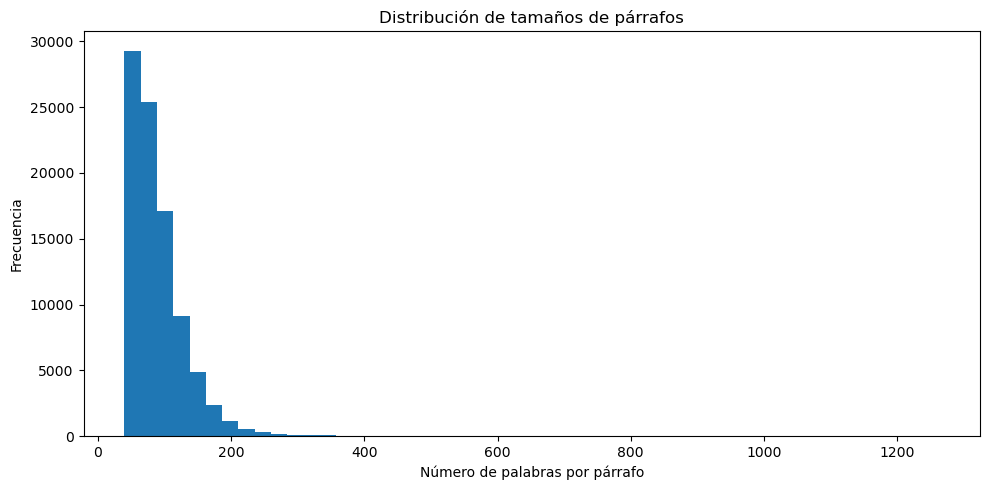

In [22]:
plt.figure(figsize=(10,5))
plt.hist(tamaños, bins=50)
plt.xlabel("Número de palabras por párrafo")
plt.ylabel("Frecuencia")
plt.title("Distribución de tamaños de párrafos")
plt.tight_layout()
plt.show()

In [23]:
np.mean(tamaños), np.median(tamaños), np.std(tamaños)

(88.6496320613378, 79.0, 42.35657055028789)

In [24]:
n_docs = len(corpus)

# numero de palabras por documento
corpus["n_palabras"] = corpus["Texto_limpio"].str.split().str.len()

stats_basicas = {
    "Número total de documentos": n_docs,
    "Palabras totales": corpus["n_palabras"].sum(),
    "Promedio palabras/doc": corpus["n_palabras"].mean(),
    "Mediana palabras/doc": corpus["n_palabras"].median(),
    "Máximo palabras/doc": corpus["n_palabras"].max(),
    "Mínimo palabras/doc": corpus["n_palabras"].min(),
    "Autores distintos": corpus["Autor"].nunique(),
    "Periódicos distintos": corpus["Diario"].nunique()
}
tabla_resumen = pd.DataFrame(stats_basicas, index=["Estadisticos"])
tabla_resumen

,Número total de documentos,Palabras totales,Promedio palabras/doc,Mediana palabras/doc,Máximo palabras/doc,Mínimo palabras/doc,Autores distintos,Periódicos distintos
Estadisticos,13676,8607289,629.371819,590.0,5223,128,584,3


# Distribución temporal

In [25]:
# Distribución temporal por mes
tabla_por_mes = (
    corpus.groupby(corpus["Fecha"].dt.to_period("M"))
    .agg(
        n_columnas=("ID","count"),
        prom_palabras=("n_palabras","mean")
    )
    .reset_index()
)

# Convertir Period a datetime para graficar
tabla_por_mes["Fecha"] = tabla_por_mes["Fecha"].dt.to_timestamp()
tabla_por_mes

,Fecha,n_columnas,prom_palabras
0,2018-01-01,532,627.088346
1,2018-02-01,476,642.428571
2,2018-03-01,453,659.867550
3,2018-04-01,478,648.202929
4,2018-05-01,555,641.639640
5,2018-06-01,361,641.728532
6,2018-07-01,284,631.658451
7,2018-08-01,372,644.669355
8,2018-09-01,407,634.611794
9,2018-10-01,409,643.904645


# Distribución columnas y autores por periodico

In [26]:
# Distribución por periódico: columnas y autores distintos
tabla_diario_autores = (
    corpus.groupby("Diario")
    .agg(
        n_columnas=("ID", "count"),
        n_autores=("Autor", "nunique")
    )
    .reset_index()
    .sort_values("n_columnas", ascending=False)
)

# Agregar porcentaje de columnas
tabla_diario_autores["% columnas"] = (
    tabla_diario_autores["n_columnas"] / len(corpus) * 100
).round(2)


tabla_diario_autores

,Diario,n_columnas,n_autores,% columnas
0,El Espectador,10509,263,76.84
1,El Tiempo,1982,249,14.49
2,Semana,1185,96,8.66


#  Riqueza léxica 

In [27]:
# Vocabulario total
tokens = " ".join(corpus["Texto_limpio"]).split()
vocabulario = set(tokens)
ttr = len(vocabulario) / len(tokens)

tabla_lexico = pd.DataFrame({
    "Métrica": ["Palabras únicas (vocab)", "Promedio únicas/doc", "TTR"],
    "Valor": [len(vocabulario),
              corpus["Texto_limpio"].apply(lambda x: len(set(x.split()))).mean(),
              ttr]
})
tabla_lexico

,Métrica,Valor
0,Palabras únicas (vocab),283940.000000
1,Promedio únicas/doc,345.299210
2,TTR,0.032988


# Gráficas

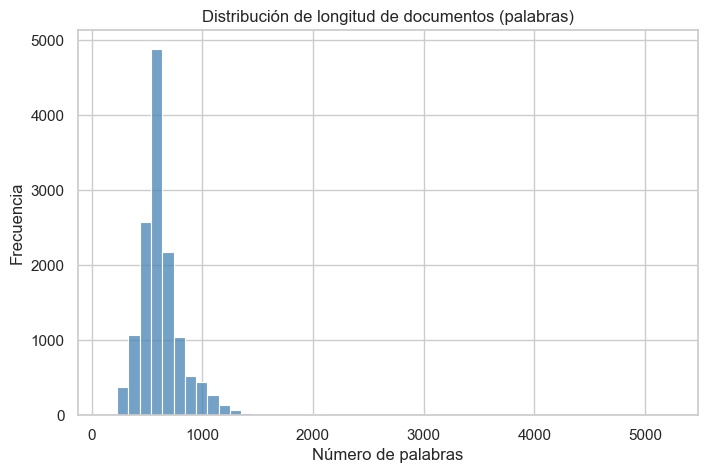

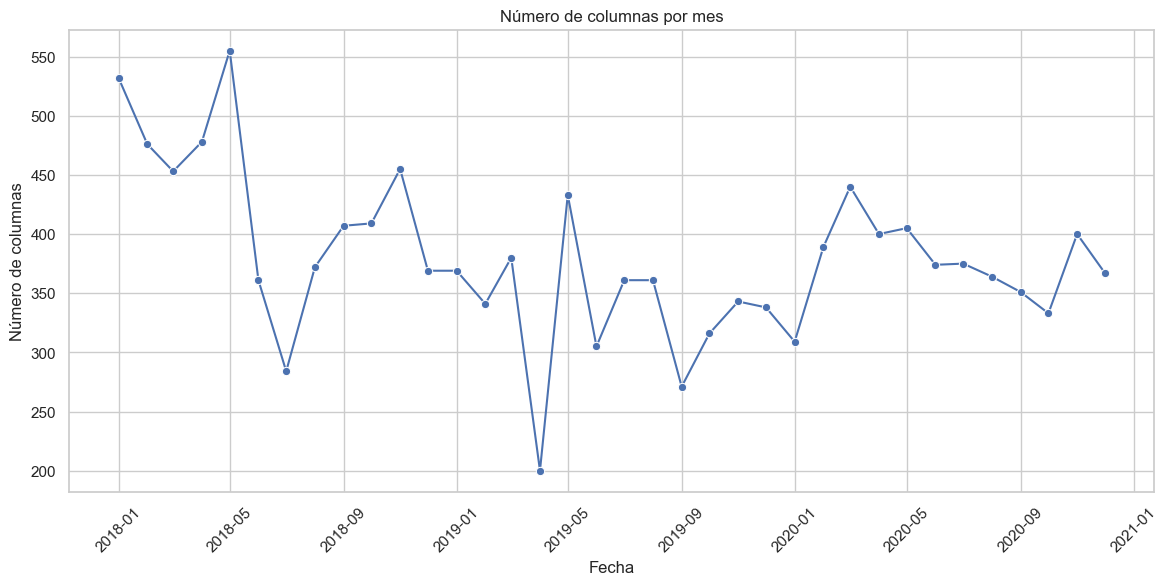

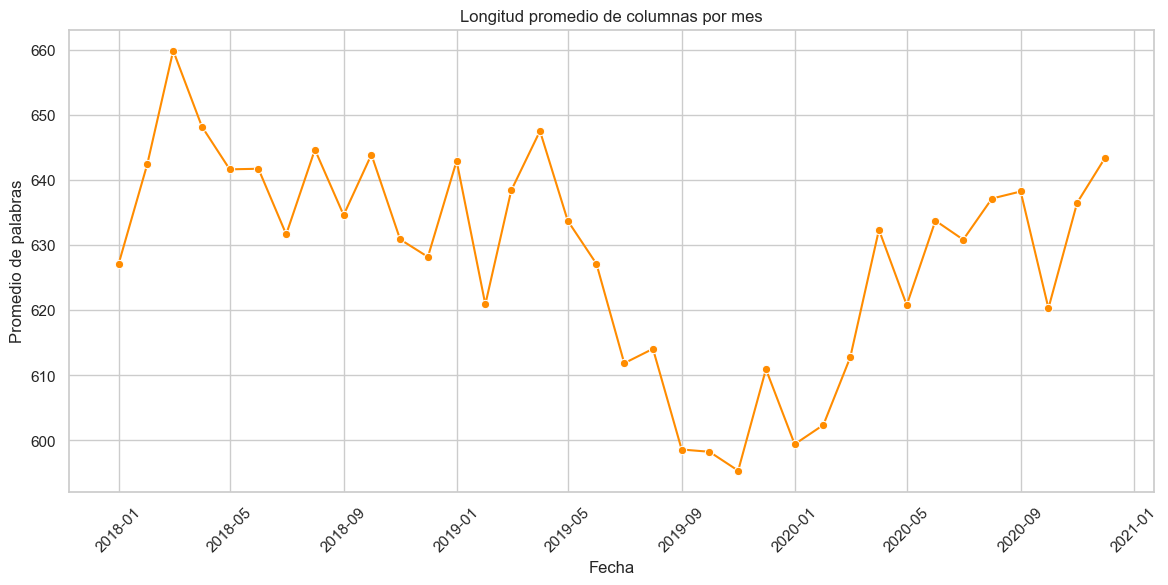

In [28]:
sns.set_theme(style="whitegrid")

# Histograma longitud
plt.figure(figsize=(8,5))
sns.histplot(corpus["n_palabras"], bins=50, color="steelblue")
plt.title("Distribución de longitud de documentos (palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

# Visualización: número de columnas por mes
plt.figure(figsize=(14,6))
sns.lineplot(data=tabla_por_mes, x="Fecha", y="n_columnas", marker="o")
plt.title("Número de columnas por mes")
plt.xlabel("Fecha")
plt.ylabel("Número de columnas")
plt.xticks(rotation=45)
plt.show()



# Visualización: longitud promedio por mes
plt.figure(figsize=(14,6))
sns.lineplot(data=tabla_por_mes, x="Fecha", y="prom_palabras", marker="o", color="darkorange")
plt.title("Longitud promedio de columnas por mes")
plt.xlabel("Fecha")
plt.ylabel("Promedio de palabras")
plt.xticks(rotation=45)
plt.show()

# Wordcloud

In [29]:
!python -m spacy download es_core_news_sm


     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
      --------------------------------------- 0.3/12.9 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.9 MB 1.3 MB/s eta 0:00:10
     --- ------------------------------------ 1.0/12.9 MB 1.3 MB/s eta 0:00:10
     ---- ----------------------------------- 1.3/12.9 MB 1.3 MB/s eta 0:00:09
     ---- ----------------------------------- 1.6/12.9 MB 1.4 MB/s eta 0:00:09
     ------ --------------------------------- 2.1/12.9 MB 1.5 MB/s eta 0:00:08
     ------- -------------------------------- 2.4/12.9 MB 1.5 MB/s eta 0:00:07
     --------- ------------------------------ 3.1/12.9 MB 1.7 MB/s eta 0:00:06
     ------------ --------------------------- 3.9/12.9 MB 1.9 MB/s eta 0:00:05
     -------------- ------------------------- 4.7/12.9 MB 2.1 MB/s eta 0:00:04
     ----------------- ---------------------- 5.5/12.9 MB 2.3 MB/s eta 0:

In [30]:
# Cargar modelo en español de spaCy
nlp = spacy.load("es_core_news_sm")

# Stopwords de spaCy
stopwords = nlp.Defaults.stop_words

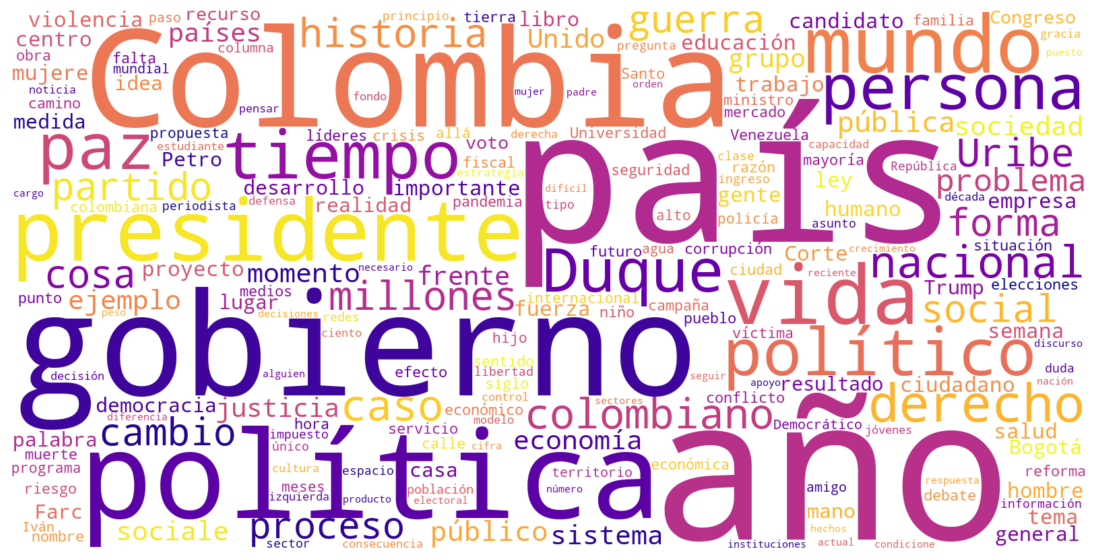

In [31]:
# Texto total
texto_total = " ".join(corpus["Texto_limpio"])

# Crear la nube sin stopwords
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    colormap="plasma",
    max_words=200,
    stopwords=stopwords,
    collocations=False,
    prefer_horizontal=1
).generate(texto_total)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\karen\\Documents\\HumanidadesDigitales_git\\reports\\ideas PAPERS\\figures\\nube_palabras.png'

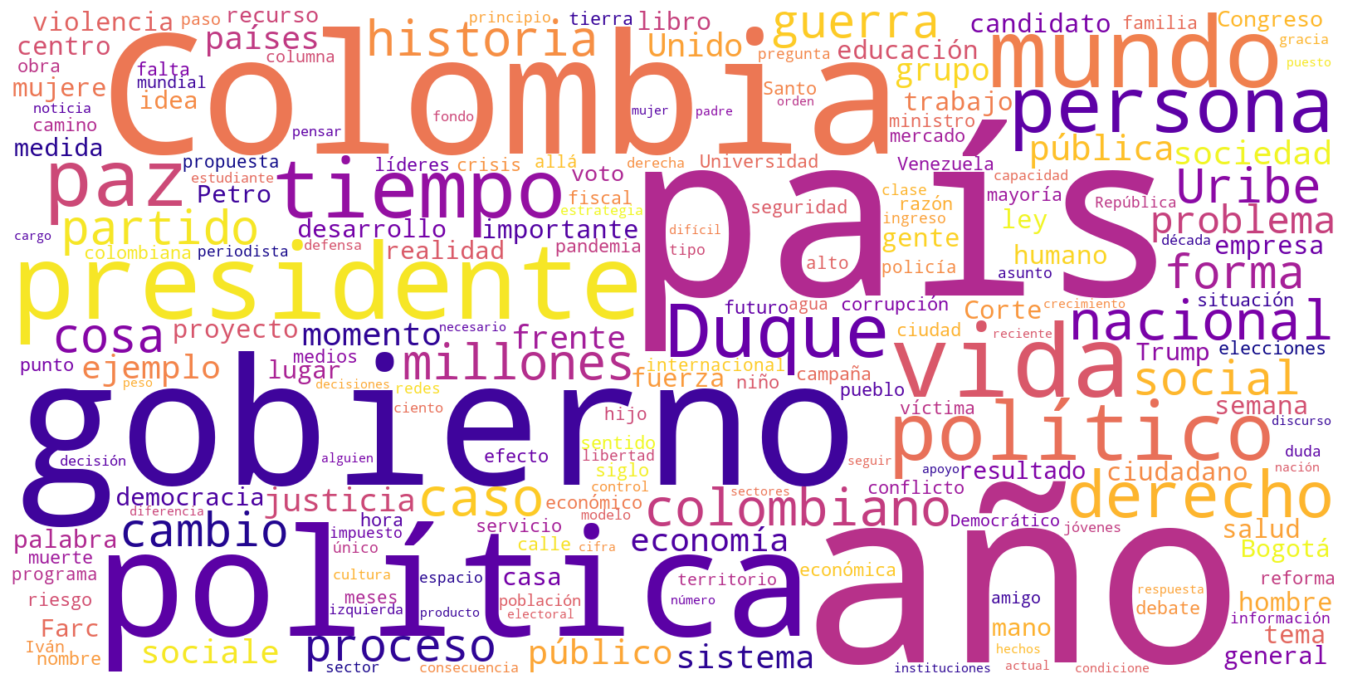

In [32]:
# Guardar en la carpeta figures
plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.savefig("../reports/ideas PAPERS/figures/nube_palabras.png", dpi=300)
plt.close()

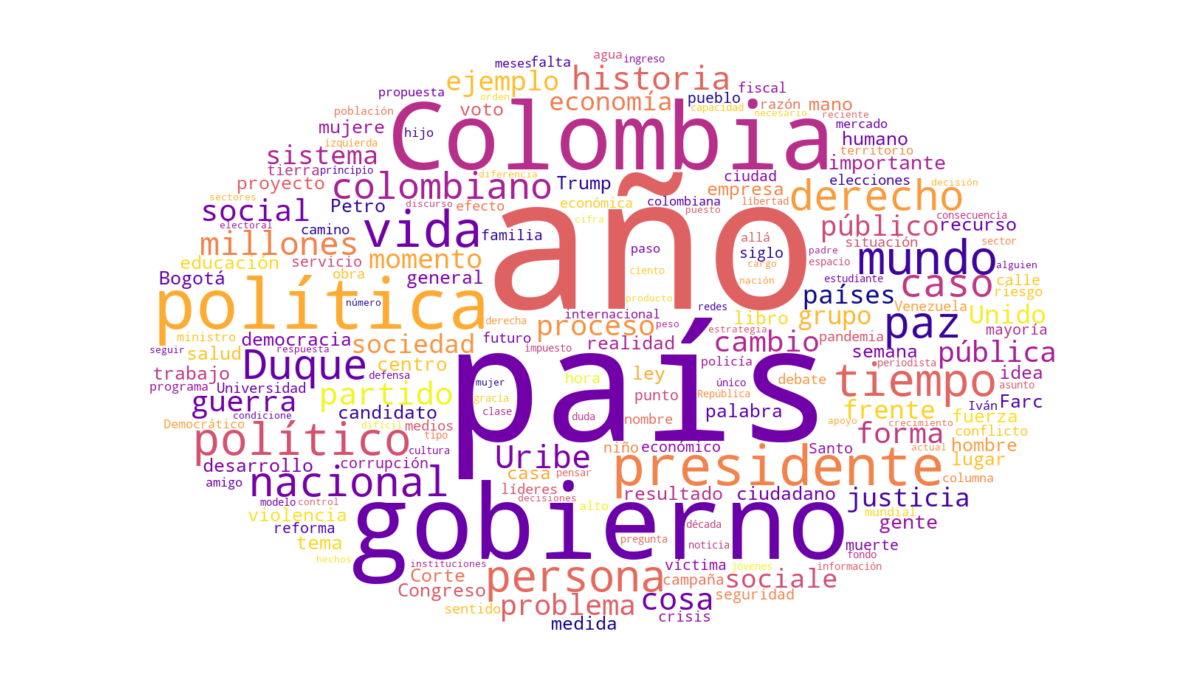

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# --- Parámetros de la máscara ---
width, height = 1600, 900

# Crear mallas de coordenadas
x, y = np.meshgrid(
    np.linspace(-1.5, 1.5, width),
    np.linspace(-1.0, 1.0, height)
)

# --- Crear máscara Gaussiana ---
# Una gaussiana suave tipo nube
sigma_x = 0.6
sigma_y = 0.45

gaussian_mask = np.exp(-(x**2 / (2 * sigma_x**2) + y**2 / (2 * sigma_y**2)))

# Convertir la gaussiana a máscara binaria
# wordcloud requiere 0 = bloqueado, 255 = permitido
threshold = 0.15
mask = (gaussian_mask > threshold).astype(np.uint8) * 255

# --- Texto total (tu corpus) ---
texto_total = " ".join(corpus["Texto_limpio"])

# --- Crear la nube ---
wordcloud = WordCloud(
    width=width,
    height=height,
    background_color="white",
    mask = 255 - mask,
    max_words=200,
    stopwords=stopwords,
    collocations=False,
    prefer_horizontal=1.0,
    relative_scaling=1.0,      # mayor contraste en tamaños
    max_font_size=None,
    random_state=42,
    colormap="plasma"
).generate(texto_total)

# --- Mostrar ---
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()
